# LOAD DAN EXPLORE DATA

In [1]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

In [2]:
X, y = make_classification(n_samples=1000, n_features=15, n_informative=10, n_redundant=2,n_clusters_per_class=1, weights=[0.9], flip_y=0, random_state=42)

In [3]:
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(1, X.shape[1] + 1)])
df['target'] = y
df['feature_12'] = np.random.choice(['A', 'B', 'C'], size=df.shape[0])
df['feature_13'] = np.random.choice(['X', 'Y', 'Z'], size=df.shape[0])

In [4]:
df

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,target
0,0.093303,-3.472520,-1.314199,3.525743,0.642138,2.247328,3.067502,1.146301,-2.173112,2.765828,-1.821258,C,Z,1.005559,-0.276558,0
1,-0.189574,-1.770842,-1.578851,-1.372201,-2.025230,0.518655,-0.764750,-3.958705,-0.598147,1.018789,4.194233,B,Z,-0.243630,0.285979,0
2,0.916269,-2.051770,3.631998,0.824844,1.674093,-0.436273,-0.460407,0.031633,-1.140149,2.069694,1.935251,B,Y,2.486020,-2.867291,0
3,-0.914665,-1.608657,-0.735184,-1.742743,-1.753532,0.383412,-1.057937,-2.897416,-0.830328,1.572469,5.334621,A,Z,-0.788215,1.255376,0
4,-0.756784,-2.362885,-3.909120,-0.474571,-4.029843,0.947114,0.581146,-3.435229,-2.142380,2.332385,3.816539,A,X,0.712335,2.810524,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.927482,-0.017325,4.884411,0.542628,3.033376,-1.904407,0.953035,1.278882,-1.293396,1.772169,-1.191263,A,Y,-0.387151,-2.629004,0
996,0.347761,-1.690916,5.949207,-2.289729,2.238469,-0.067922,-0.069702,-1.436622,-2.153011,-0.867583,3.962758,A,Y,0.886822,-1.248408,0
997,1.201967,-1.263417,-1.331925,-2.468434,1.777577,2.270456,-0.431749,-1.846263,1.753033,1.858452,4.264568,A,Y,0.067260,0.931995,1
998,-2.127846,-0.975838,0.279144,0.151578,-0.443749,0.650616,-1.410265,-1.017319,-0.643070,2.142898,3.399255,C,Y,-0.128774,0.800834,0


In [5]:
X = df.drop('target', axis=1)
y = df['target']

In [6]:
Counter(y)

Counter({0: 901, 1: 99})

# FEATURE SELECTION

In [7]:
# Menggunakan Random Forest untuk mendapatkan fitur penting
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
X_integer = X.drop(['feature_12', 'feature_13'], axis=1)
rf_model.fit(X_integer, y)
 
# Nilai kepentingan fitur
importances = rf_model.feature_importances_
 
# Indeks fitur penting
threshold = 0.05  # Misalnya, ambang batas 5%
important_features_indices = [i for i in range(len(importances)) if importances[i] >= threshold]
 
# Menampilkan fitur penting beserta nilainya
print("Fitur yang dipilih dengan Embedded Methods (di atas ambang batas):")
for i in important_features_indices:
    print(f"{X_integer.columns[i]}: {importances[i]}")
 
# Nama fitur penting 
important_features = X_integer.columns[important_features_indices]
 
# DF fitur penting
X_important = X_integer[important_features]  

Fitur yang dipilih dengan Embedded Methods (di atas ambang batas):
feature_2: 0.11860019897866206
feature_3: 0.06878603593465271
feature_5: 0.07731131335837178
feature_8: 0.050482655781999855
feature_9: 0.2625049418105367
feature_10: 0.08958259568334655
feature_11: 0.06365230544114515
feature_15: 0.12578161860669113


In [8]:
X_selected = pd.concat([X_important, X[['feature_12', 'feature_13']]], axis=1)
X_selected.head()

,feature_2,feature_3,feature_5,feature_8,feature_9,feature_10,feature_11,feature_15,feature_12,feature_13
0,-3.472520,-1.314199,0.642138,1.146301,-2.173112,2.765828,-1.821258,-0.276558,C,Z
1,-1.770842,-1.578851,-2.025230,-3.958705,-0.598147,1.018789,4.194233,0.285979,B,Z
2,-2.051770,3.631998,1.674093,0.031633,-1.140149,2.069694,1.935251,-2.867291,B,Y
3,-1.608657,-0.735184,-1.753532,-2.897416,-0.830328,1.572469,5.334621,1.255376,A,Z
4,-2.362885,-3.909120,-4.029843,-3.435229,-2.142380,2.332385,3.816539,2.810524,A,X


# ENCODING

In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
X_selected['feature_12'] = label_encoder.fit_transform(X_selected['feature_12'])
X_selected['feature_13'] = label_encoder.fit_transform(X_selected['feature_13'])
X_selected.head()

,feature_2,feature_3,feature_5,feature_8,feature_9,feature_10,feature_11,feature_15,feature_12,feature_13
0,-3.472520,-1.314199,0.642138,1.146301,-2.173112,2.765828,-1.821258,-0.276558,2,2
1,-1.770842,-1.578851,-2.025230,-3.958705,-0.598147,1.018789,4.194233,0.285979,1,2
2,-2.051770,3.631998,1.674093,0.031633,-1.140149,2.069694,1.935251,-2.867291,1,1
3,-1.608657,-0.735184,-1.753532,-2.897416,-0.830328,1.572469,5.334621,1.255376,0,2
4,-2.362885,-3.909120,-4.029843,-3.435229,-2.142380,2.332385,3.816539,2.810524,0,0


# HANDLE OUTLIERS

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
 
# Memilih kolom numerik
numeric_columns = X_selected.select_dtypes(include=['float64', 'int64']).columns
numeric_columns = numeric_columns.drop(['feature_12', 'feature_13'])
 
# Membuat salinan data untuk menjaga data asli tetap utuh
X_cleaned = X_important.copy()
X_cleaned.shape

(1000, 8)

In [11]:
for col in numeric_columns:
    # Melihat outlier dengan IQR (Interquartile Range)
    Q1 = X_important[col].quantile(0.25)
    Q3 = X_important[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identifikasi outlier
    outliers = X_cleaned[(X_cleaned[col] < lower_bound) | (X_cleaned[col] > upper_bound)]
    
    # Menghapus outlier dari DataFrame
    X_cleaned = X_cleaned.drop(outliers.index)
    y = y.drop(outliers.index)

In [12]:
X_cleaned.shape

(949, 8)

# SMOTE (SYNTETIC DATA)

In [13]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_cleaned, y)
print(f" Distribusi kelas target: {Counter(y_resampled)}")

 Distribusi kelas target: Counter({0: 875, 1: 875})


# SCALING

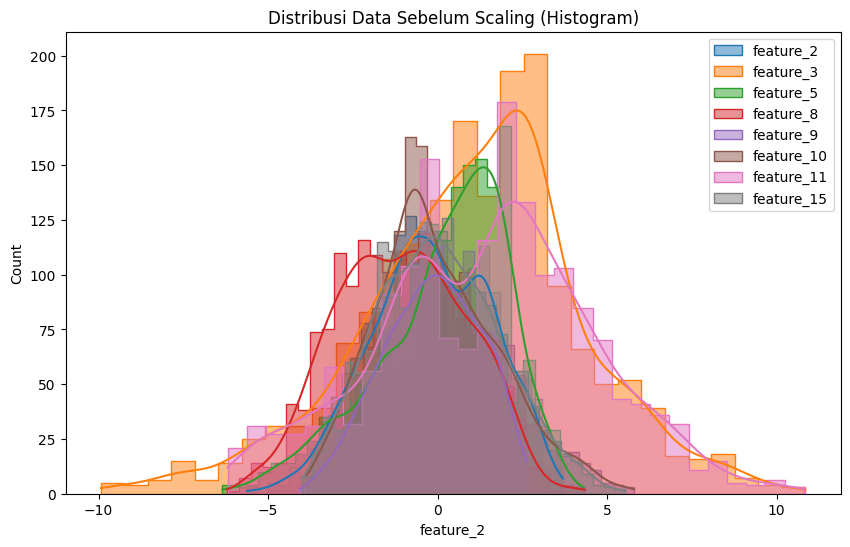

In [14]:
# 1. Visualisasi distribusi data sebelum scaling menggunakan histogram
plt.figure(figsize=(10, 6))
for col in X_resampled.columns:
    sns.histplot(X_resampled[col], kde=True, label=col, bins=30, element='step')
plt.title('Distribusi Data Sebelum Scaling (Histogram)')
plt.legend()
plt.show()

In [15]:
scaler = StandardScaler()
X_resampled[important_features] = scaler.fit_transform(X_resampled[important_features])

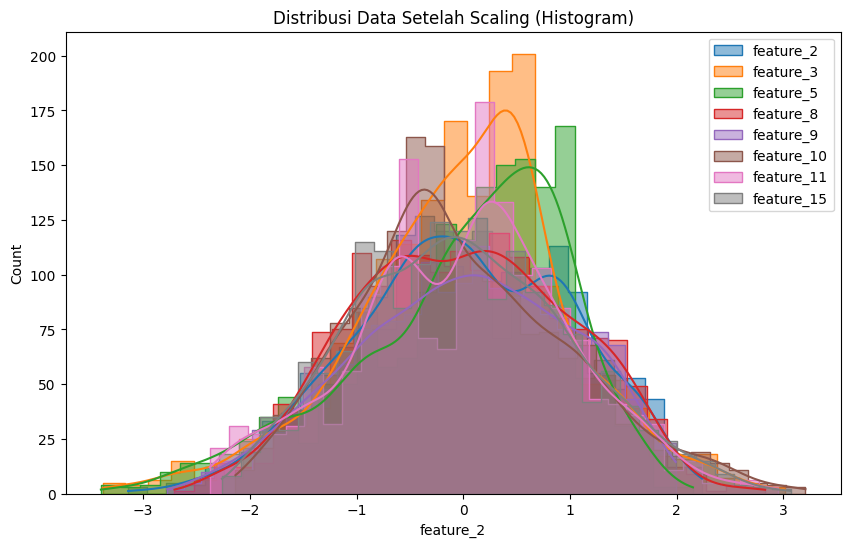

In [17]:
# 1. Visualisasi distribusi data setelah scaling menggunakan histogram
plt.figure(figsize=(10, 6))
for col in X_resampled.columns:
    sns.histplot(X_resampled[col], kde=True, label=col, bins=30, element='step')
plt.title('Distribusi Data Setelah Scaling (Histogram)')
plt.legend()
plt.show()

In [18]:
X_resampled.head()

,feature_2,feature_3,feature_5,feature_8,feature_9,feature_10,feature_11,feature_15
0,-1.901503,-0.727429,0.243840,1.154880,-1.420918,1.533794,-1.006477,-0.177863
1,-0.919361,-0.808862,-1.145007,-1.521662,-0.301437,0.567300,0.878054,0.136200
2,-1.081501,0.794512,0.781160,0.570462,-0.686691,1.148680,0.170361,-1.624266
3,-0.825754,-0.549266,-1.003539,-0.965231,-0.466471,0.873606,1.235314,0.677413
4,-1.261065,-1.525884,-2.188770,-1.247205,-1.399074,1.294006,0.759730,1.545650


# BINNING